In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import os
import sys
sys.path.append(os.path.abspath('..'))

from dcgan import Generator, Discriminator, weights_init
from utils.metrics import fid
from utils.utils import return_device, return_photos

In [2]:
device = return_device()

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../../archive/lfw-deepfunneled'

all_photos = return_photos(PATH_TO_PHOTOS)

100%|██████████| 13233/13233 [00:12<00:00, 1043.02it/s]

Photos uploaded: 13233


In [4]:
batch_size=128

train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=batch_size)

# DCGAN

The original (2015) convolutional GAN, generating 64x64 faces from noise.
Unlike the autoencoder models, there is no encoder: a generator maps random latent vectors directly to images, trained adversarially against a discriminator.

Works in [-1, 1] (tanh output). FID at the end is computed in the canonical [0, 1] scale.

  0%|          | 0/100 [00:00<?, ?it/s]

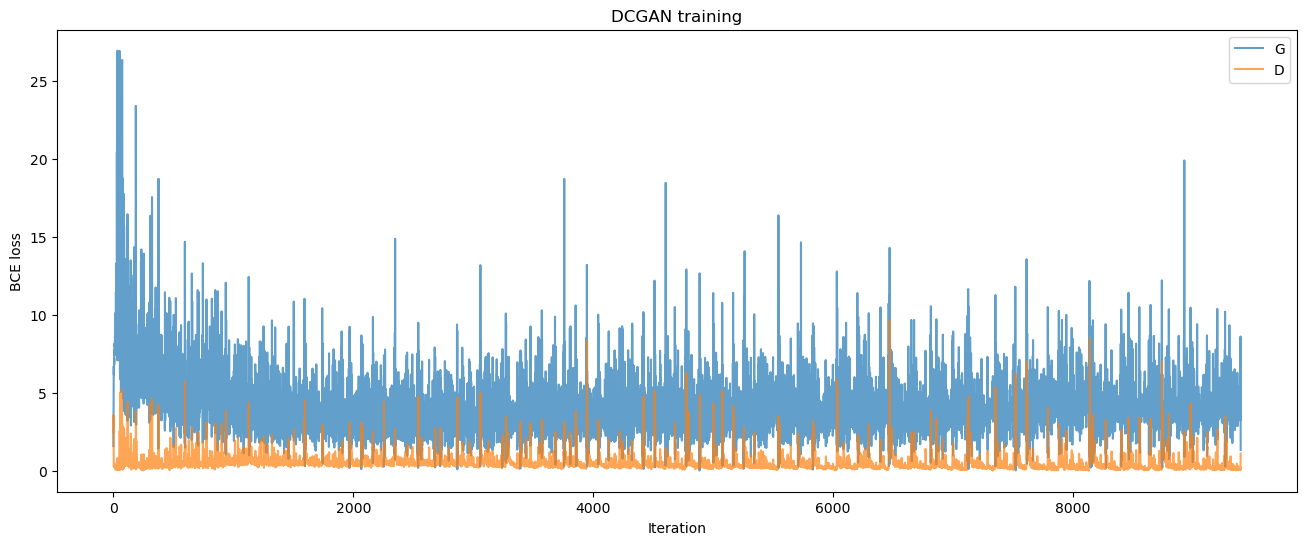

In [5]:
latent_dim = 100

modelG = Generator(latent_dim=latent_dim).to(device)
modelG.apply(weights_init)

modelD = Discriminator().to(device)
modelD.apply(weights_init)

optimizerG = torch.optim.Adam(modelG.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerD = torch.optim.Adam(modelD.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()  # discriminator outputs a probability (sigmoid)

n_epochs = 100
real_label, fake_label = 1.0, 0.0
loss_G, loss_D = [], []

for epoch in tqdm(range(n_epochs)):
    for batch in train_loader:
        real = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 127.5 - 1   # -> [-1,1]
        bs = real.size(0)

        # Discriminator
        modelD.zero_grad()
        out_real = modelD(real)
        lossD_real = criterion(out_real, torch.full_like(out_real, real_label))
        noise = torch.randn(bs, latent_dim, 1, 1, device=device)
        fake = modelG(noise)
        out_fake = modelD(fake.detach())
        lossD_fake = criterion(out_fake, torch.full_like(out_fake, fake_label))
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # Generator
        modelG.zero_grad()
        out = modelD(fake)
        lossG = criterion(out, torch.full_like(out, real_label))   # G wants D to call fakes real
        lossG.backward()
        optimizerG.step()

        loss_G.append(lossG.item())
        loss_D.append(lossD.item())

torch.save(modelG.state_dict(), '../checkpoints/dcgan_generation.pt')

plt.figure(figsize=(16, 6))
plt.plot(loss_G, label='G', alpha=0.7)
plt.plot(loss_D, label='D', alpha=0.7)
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('BCE loss')
plt.title('DCGAN training')
plt.show()

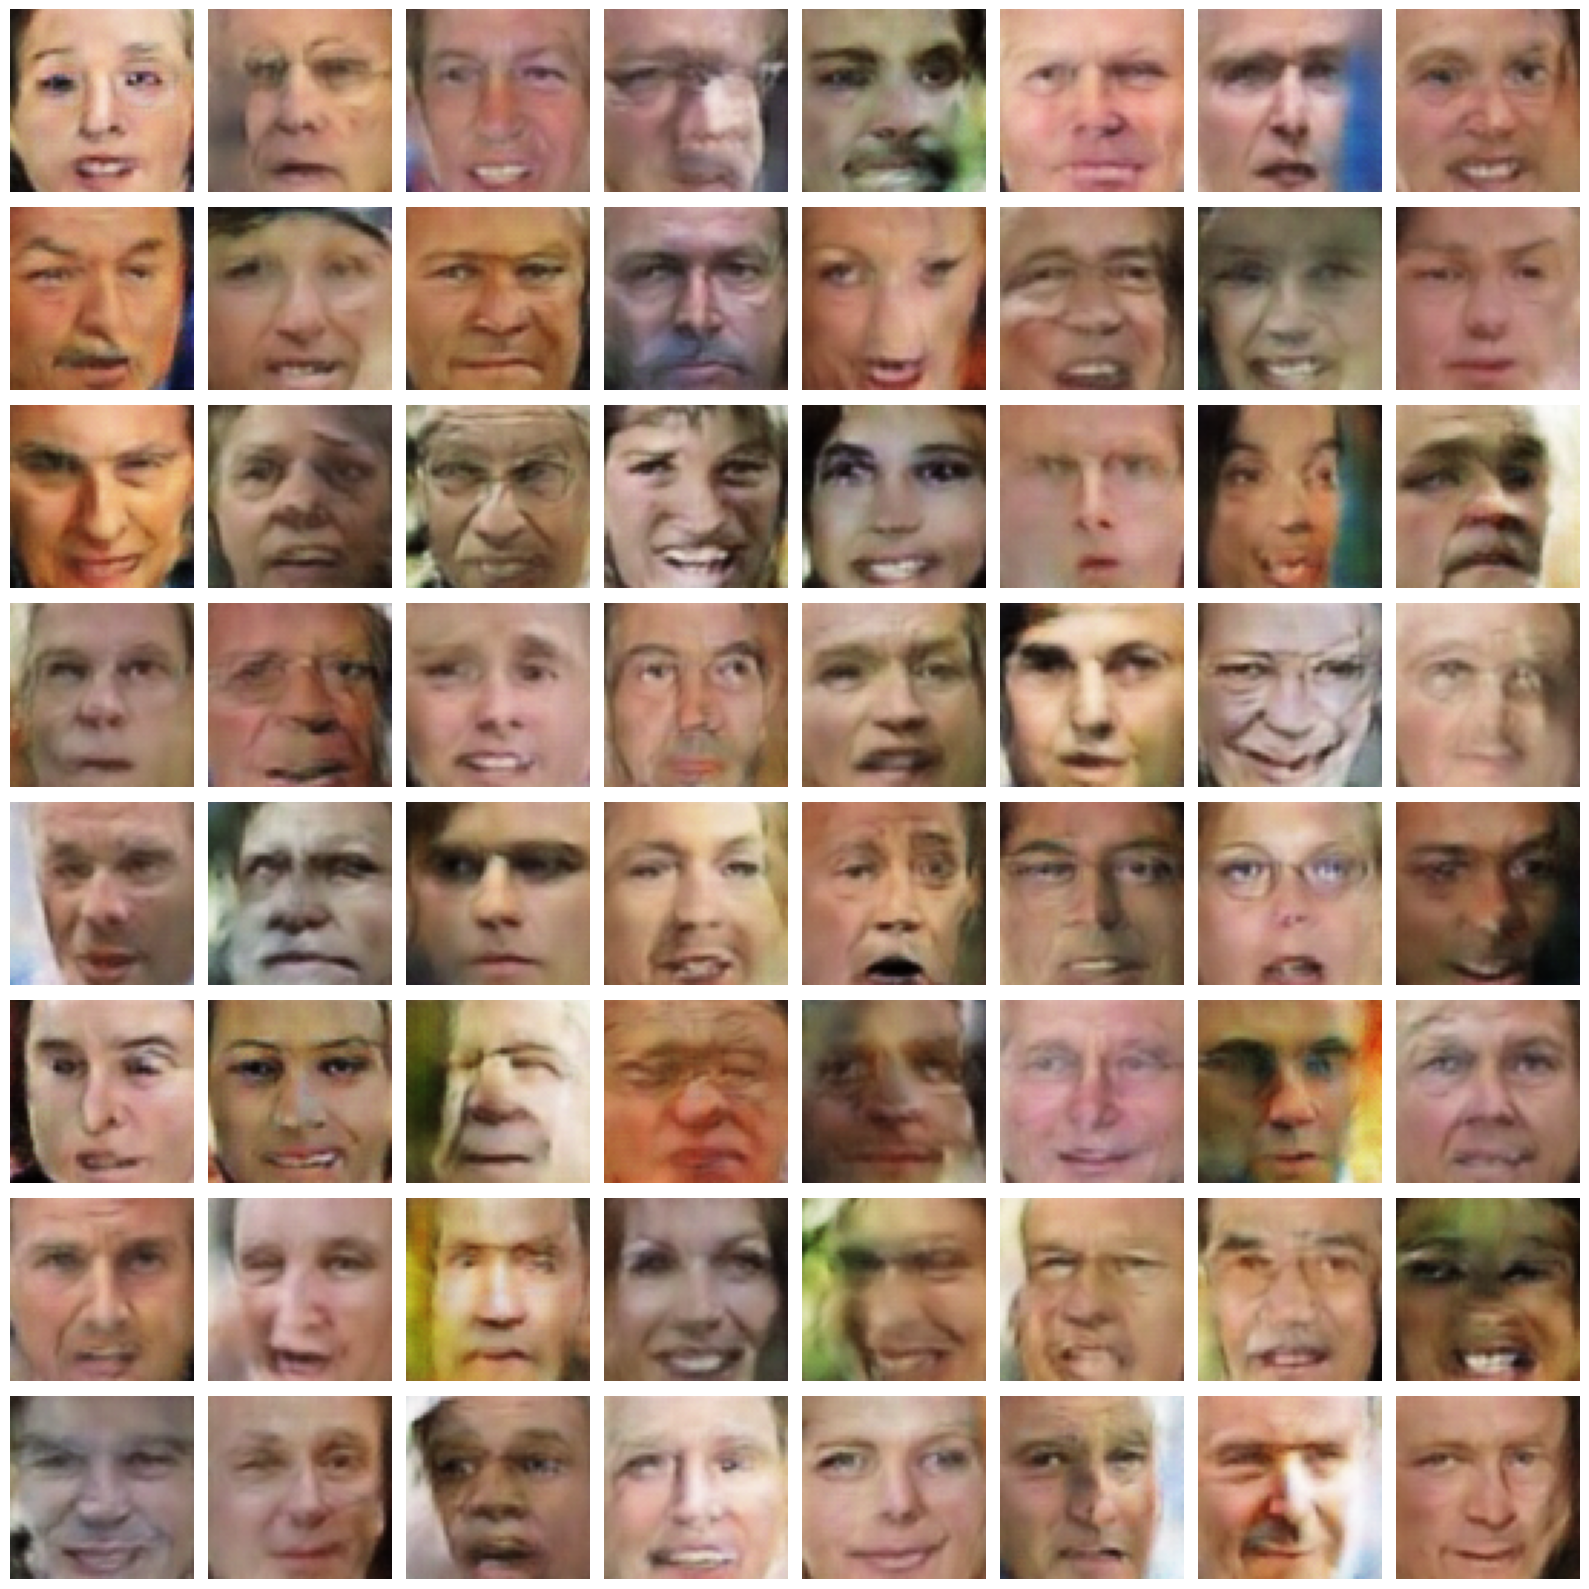

In [6]:
modelG.eval()
with torch.no_grad():
    noise = torch.randn(64, latent_dim, 1, 1, device=device)
    fake = modelG(noise).cpu().permute(0, 2, 3, 1)
    fake = ((fake + 1) * 0.5).clip(0, 1)  # [-1,1] -> [0,1]

fig, axes = plt.subplots(8, 8, figsize=(16, 16))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(fake[idx].numpy())
    ax.axis('off')
    
plt.tight_layout()
plt.show()